# 06. Compare 192-component mutational spectra by MITOMAP functional class

This notebook separates the strand-oriented 192-component mtDNA spectrum into three canonical functional classes defined from the MITOMAP Genome Loci table:

- `protein_coding`: the 13 canonical protein-coding genes;
- `rna_coding`: 22 tRNA genes plus `MT-RNR1` and `MT-RNR2`;
- `control_region`: the circular `MT-CR` interval, 16024-576.

The class is assigned from the central mutated position. Before opportunities and spectrum weights are calculated, variants in canonical loci marked `[on complement]` by MITOMAP are reverse-complemented into the functional-strand orientation; original rCRS-oriented fields are retained with an `_rcrs` suffix. Overlapping genes within the same class are collapsed to one opportunity position, while all matching locus names remain in the annotation.

The primary spectrum uses class-specific trinucleotide opportunity counts. Genome-wide opportunity normalization and raw-count spectra are retained as sensitivity analyses. As in notebook 05, carrier-count weighting makes these population spectra descriptive rather than independent estimates of mutation-process event rates.

In [1]:
import hashlib
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("../scripts").resolve()))
from mutspec192_ci import (
    SBS192_REFERENCE_ORDER,
    estimate_shared_spectrum_uncertainty,
    plot_mutspec192_difference_with_ci,
    plot_mutspec192_with_ci,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 240)

In [2]:
# ============================================================
# Paths, source metadata, and deterministic category order
# ============================================================

MITOMAP_SOURCE_URL = "https://www.mitomap.org/foswiki/bin/view/MITOMAP/GenomeLoci"
MITOMAP_LOCI_INPUT = Path("../data/raw/mitomap/mitomap_genome_loci_192_r889.tsv")
MITOMAP_METADATA_INPUT = Path(
    "../data/raw/mitomap/mitomap_genome_loci_192_r889.metadata.json"
)
EXPECTED_MITOMAP_TSV_SHA256 = "7d396431a03109917a889b6a37f4d887f5cb1745e92fe9d15fb4f91b74dc8ed1"
EXPECTED_MITOMAP_REVISION = "r889"

WEIGHTED_INPUT = Path(
    "../results/spectrum_groups/spectrum_groups_with_weights_192_T95.tsv"
)

MITOMAP_PROCESSED_DIR = Path("../data/processed/mitomap")
SPECTRUM_OUTPUT_DIR = Path("../results/mutation_spectra")
SPECTRUM_GROUP_OUTPUT_DIR = Path("../results/spectrum_groups")
FIGURE_DIR = Path("../results/figures/functional_class_spectra_192_T95")

for output_dir in [
    MITOMAP_PROCESSED_DIR,
    SPECTRUM_OUTPUT_DIR,
    SPECTRUM_GROUP_OUTPUT_DIR,
    FIGURE_DIR,
]:
    output_dir.mkdir(parents=True, exist_ok=True)

SELECTED_LOCI_OUTPUT = MITOMAP_PROCESSED_DIR / "mitomap_functional_loci_192_r889.tsv"
POSITION_ANNOTATION_OUTPUT = (
    MITOMAP_PROCESSED_DIR / "mitomap_position_functional_class_192_r889.tsv"
)
ANNOTATED_VARIANTS_OUTPUT = (
    SPECTRUM_GROUP_OUTPUT_DIR
    / "spectrum_groups_with_weights_functional_classes_192_T95.tsv"
)
SPECTRUM_OUTPUT = (
    SPECTRUM_OUTPUT_DIR / "functional_class_spectra_192_T95.tsv"
)
SUMMARY_OUTPUT = (
    SPECTRUM_OUTPUT_DIR / "functional_class_spectrum_summary_192_T95.tsv"
)
TOP_VARIANTS_OUTPUT = (
    SPECTRUM_OUTPUT_DIR / "functional_class_top_contributors_192_T95.tsv"
)
POSITION_QC_OUTPUT = (
    SPECTRUM_OUTPUT_DIR / "functional_class_position_qc_192_T95.tsv"
)
UNCERTAINTY_OUTPUT = (
    SPECTRUM_OUTPUT_DIR / "functional_class_spectrum_uncertainty_192_T95.tsv"
)
DIFFERENCE_UNCERTAINTY_OUTPUT = (
    SPECTRUM_OUTPUT_DIR
    / "functional_class_spectrum_difference_uncertainty_192_T95.tsv"
)
N_BOOTSTRAP_SIMULATIONS = 4000
BOOTSTRAP_RANDOM_SEED = 20260810

GENOME_LENGTH = 16569
GROUP_COL = "spectrum_group_primary_T95"
GROUP_ORDER = [
    "expanded_neutral_like_T95",
    "unlabeled_out_of_neutral_domain_T95",
]
FUNCTIONAL_CLASS_ORDER = [
    "protein_coding",
    "rna_coding",
    "control_region",
]

substitution_order_12 = [
    "A>C", "A>G", "A>T",
    "C>A", "C>G", "C>T",
    "G>A", "G>C", "G>T",
    "T>A", "T>C", "T>G",
]
substitution_order_192 = [
    f"{left}[{substitution}]{right}"
    for left in "ACGT"
    for substitution in substitution_order_12
    for right in "ACGT"
]

assert len(substitution_order_192) == 192
assert len(set(substitution_order_192)) == 192

## Load and validate the versioned MITOMAP export

The public page renders its table from a JavaScript `data` array rather than a static HTML table. `scripts/export_mitomap_functional_loci_192.py` downloads that page and exports a clean, versioned TSV plus JSON provenance. This notebook reads only the exported table and checksum-locks its normalized content so unrelated changes elsewhere in the HTML cannot invalidate the analysis.

In [3]:
metadata = json.loads(MITOMAP_METADATA_INPUT.read_text(encoding="utf-8"))
required_metadata_fields = {
    "source_url", "source_revision", "source_last_edited",
    "record_count", "genome_length", "tsv_file", "tsv_sha256",
}
missing_metadata_fields = sorted(required_metadata_fields.difference(metadata))
if missing_metadata_fields:
    raise ValueError(f"Missing MITOMAP metadata fields: {missing_metadata_fields}")

tsv_sha256 = hashlib.sha256(MITOMAP_LOCI_INPUT.read_bytes()).hexdigest()
if (
    tsv_sha256 != EXPECTED_MITOMAP_TSV_SHA256
    or tsv_sha256 != metadata["tsv_sha256"]
):
    raise ValueError(
        "MITOMAP TSV checksum changed. Review the new source revision and "
        "the explicit locus whitelist before continuing."
    )
if metadata["source_url"] != MITOMAP_SOURCE_URL:
    raise ValueError("Unexpected MITOMAP source URL.")
if metadata["source_revision"] != EXPECTED_MITOMAP_REVISION:
    raise ValueError(
        f"Expected MITOMAP {EXPECTED_MITOMAP_REVISION}, "
        f"found {metadata['source_revision']}."
    )
if metadata["genome_length"] != GENOME_LENGTH:
    raise ValueError("MITOMAP metadata has an unexpected genome length.")
if metadata["tsv_file"] != MITOMAP_LOCI_INPUT.name:
    raise ValueError("MITOMAP metadata points to a different TSV file.")

source_loci_cols = [
    "map_locus", "start", "end", "shorthand", "description",
    "reference_count", "reference_ids", "reference_url",
]
loci = pd.read_csv(
    MITOMAP_LOCI_INPUT,
    sep="\t",
    keep_default_na=False,
    dtype={
        "map_locus": "string",
        "shorthand": "string",
        "description": "string",
        "reference_ids": "string",
        "reference_url": "string",
    },
)
if list(loci.columns) != source_loci_cols:
    raise ValueError(f"Unexpected MITOMAP TSV schema: {list(loci.columns)}")
loci["start"] = pd.to_numeric(loci["start"], errors="raise").astype(int)
loci["end"] = pd.to_numeric(loci["end"], errors="raise").astype(int)
loci["reference_count"] = pd.to_numeric(
    loci["reference_count"], errors="raise"
).astype(int)
if len(loci) != metadata["record_count"] or len(loci) != 87:
    raise ValueError("Unexpected MITOMAP locus table size.")
if loci["map_locus"].duplicated().any():
    raise ValueError("Duplicate MITOMAP locus names.")
if not loci[["start", "end"]].apply(
    lambda col: col.between(1, GENOME_LENGTH)
).all().all():
    raise ValueError("MITOMAP coordinates fall outside the rCRS range.")

source_revision = metadata["source_revision"]
source_last_edited = metadata["source_last_edited"]
loci["source_url"] = MITOMAP_SOURCE_URL
loci["source_revision"] = source_revision
loci["source_last_edited"] = source_last_edited
loci["source_sha256"] = tsv_sha256

loci_output_cols = source_loci_cols + [
    "source_url", "source_revision", "source_last_edited", "source_sha256",
]

print("MITOMAP source:", MITOMAP_SOURCE_URL)
print("Exported table:", MITOMAP_LOCI_INPUT)
print("Revision:", source_revision)
print("Last edited:", source_last_edited)
print("TSV SHA256:", tsv_sha256)
print("Loaded loci:", len(loci))
display(loci[loci_output_cols].head())

MITOMAP source: https://www.mitomap.org/foswiki/bin/view/MITOMAP/GenomeLoci
Exported table: ..\data\raw\mitomap\mitomap_genome_loci_192_r889.tsv
Revision: r889
Last edited: Jul 13, 2026
TSV SHA256: 7d396431a03109917a889b6a37f4d887f5cb1745e92fe9d15fb4f91b74dc8ed1
Loaded loci: 87


,map_locus,start,end,shorthand,description,reference_count,reference_ids,reference_url,source_url,source_revision,source_last_edited,source_sha256
0,MT-OHR57,57,57,CR:OH57,H-strand origin,1,4798,https://www.mitomap.org/cgi-bin/print_ref_list...,https://www.mitomap.org/foswiki/bin/view/MITOM...,r889,"Jul 13, 2026",7d396431a03109917a889b6a37f4d887f5cb1745e92fe9...
1,MT-HV2,57,372,CR:HVS2,Hypervariable segment 2 [classic:73-340 ],3,"2,140,3056",https://www.mitomap.org/cgi-bin/print_ref_list...,https://www.mitomap.org/foswiki/bin/view/MITOM...,r889,"Jul 13, 2026",7d396431a03109917a889b6a37f4d887f5cb1745e92fe9...
2,MT-OHR,110,441,CR:OH,H-strand origins,4,"65,95,546,4798",https://www.mitomap.org/cgi-bin/print_ref_list...,https://www.mitomap.org/foswiki/bin/view/MITOM...,r889,"Jul 13, 2026",7d396431a03109917a889b6a37f4d887f5cb1745e92fe9...
3,MT-CSB1,213,235,CR:CSB1,Conserved sequence block 1,2,"65,91928",https://www.mitomap.org/cgi-bin/print_ref_list...,https://www.mitomap.org/foswiki/bin/view/MITOM...,r889,"Jul 13, 2026",7d396431a03109917a889b6a37f4d887f5cb1745e92fe9...
4,MT-TFX,233,260,CR:TFX,mtTF1 binding site,1,122,https://www.mitomap.org/cgi-bin/print_ref_list...,https://www.mitomap.org/foswiki/bin/view/MITOM...,r889,"Jul 13, 2026",7d396431a03109917a889b6a37f4d887f5cb1745e92fe9...


## Build canonical position-level functional classes

Explicit whitelists prevent newly described overlapping microproteins, regulatory subfeatures, or the 5S-like `MT-RNR3` interval from redefining the three canonical classes. All 87 MITOMAP locus memberships are still retained in `mitomap_all_loci` for traceability.

In [4]:
PROTEIN_LOCI = (
    "MT-ND1", "MT-ND2", "MT-CO1", "MT-CO2", "MT-ATP8",
    "MT-ATP6", "MT-CO3", "MT-ND3", "MT-ND4L", "MT-ND4",
    "MT-ND5", "MT-ND6", "MT-CYB",
)
RNA_LOCI = (
    "MT-TF", "MT-RNR1", "MT-TV", "MT-RNR2", "MT-TL1", "MT-TI",
    "MT-TQ", "MT-TM", "MT-TW", "MT-TA", "MT-TN", "MT-TC",
    "MT-TY", "MT-TS1", "MT-TD", "MT-TK", "MT-TG", "MT-TR",
    "MT-TH", "MT-TS2", "MT-TL2", "MT-TE", "MT-TT", "MT-TP",
)
CONTROL_REGION_LOCI = ("MT-CR",)
EXPECTED_COMPLEMENT_LOCI = {
    "MT-ND6", "MT-TQ", "MT-TA", "MT-TN", "MT-TC",
    "MT-TY", "MT-TS1", "MT-TE", "MT-TP",
}

expected_loci = set(PROTEIN_LOCI) | set(RNA_LOCI) | set(CONTROL_REGION_LOCI)
observed_loci = set(loci["map_locus"])
missing_expected_loci = sorted(expected_loci - observed_loci)
if missing_expected_loci:
    raise ValueError(f"Expected MITOMAP loci are missing: {missing_expected_loci}")

class_by_locus = {
    **{locus: "protein_coding" for locus in PROTEIN_LOCI},
    **{locus: "rna_coding" for locus in RNA_LOCI},
    **{locus: "control_region" for locus in CONTROL_REGION_LOCI},
}
selected_loci = loci[loci["map_locus"].isin(expected_loci)].copy()
selected_loci["functional_class"] = selected_loci["map_locus"].map(class_by_locus)
selected_loci["is_complement_strand"] = (
    selected_loci["description"].str.contains(
        "[on complement]", regex=False, na=False
    )
)
selected_loci["functional_strand"] = np.where(
    selected_loci["is_complement_strand"], "complement", "reference"
)
selected_loci = selected_loci.sort_values(["start", "end", "map_locus"])
observed_complement_loci = set(
    selected_loci.loc[selected_loci["is_complement_strand"], "map_locus"]
)
if observed_complement_loci != EXPECTED_COMPLEMENT_LOCI:
    raise ValueError(
        "Unexpected canonical complement-strand loci: "
        f"{sorted(observed_complement_loci)}"
    )

selected_counts = selected_loci["functional_class"].value_counts().to_dict()
expected_locus_counts = {
    "protein_coding": 13,
    "rna_coding": 24,
    "control_region": 1,
}
if selected_counts != expected_locus_counts:
    raise ValueError(
        f"Unexpected selected locus counts: {selected_counts}"
    )

selected_loci[
    ["functional_class", "functional_strand", "is_complement_strand"]
    + loci_output_cols
].to_csv(SELECTED_LOCI_OUTPUT, sep="\t", index=False)


def expand_circular_interval(start, end, genome_length=GENOME_LENGTH):
    start = int(start)
    end = int(end)
    if start <= end:
        return range(start, end + 1)
    return list(range(start, genome_length + 1)) + list(range(1, end + 1))


all_membership_records = []
for row in loci.itertuples(index=False):
    for position in expand_circular_interval(row.start, row.end):
        all_membership_records.append({
            "position": position,
            "map_locus": row.map_locus,
            "description": row.description,
        })
all_membership = pd.DataFrame(all_membership_records)
all_by_position = (
    all_membership.groupby("position", as_index=False)
    .agg(
        mitomap_all_loci=(
            "map_locus", lambda values: ";".join(sorted(set(values)))
        ),
        mitomap_all_descriptions=(
            "description", lambda values: " | ".join(sorted(set(values)))
        ),
    )
)

class_membership_records = []
for row in selected_loci.itertuples(index=False):
    for position in expand_circular_interval(row.start, row.end):
        class_membership_records.append({
            "position": position,
            "functional_class": row.functional_class,
            "functional_strand": row.functional_strand,
            "is_complement_strand": row.is_complement_strand,
            "mitomap_class_locus": row.map_locus,
        })
class_membership = pd.DataFrame(class_membership_records)

cross_class_membership = (
    class_membership.groupby("position")["functional_class"].nunique()
)
if (cross_class_membership > 1).any():
    bad_positions = cross_class_membership[cross_class_membership > 1].index.tolist()
    raise ValueError(f"Cross-class MITOMAP overlaps: {bad_positions[:20]}")
class_by_position = (
    class_membership.groupby("position", as_index=False)
    .agg(
        functional_class=("functional_class", "first"),
        is_complement_strand=("is_complement_strand", "max"),
        mitomap_class_loci=(
            "mitomap_class_locus",
            lambda values: ";".join(sorted(set(values))),
        ),
        n_mitomap_class_loci=("mitomap_class_locus", "nunique"),
    )
)
class_by_position["functional_strand"] = np.where(
    class_by_position["is_complement_strand"],
    "complement",
    "reference",
)

position_annotation = pd.DataFrame({"position": range(1, GENOME_LENGTH + 1)})
position_annotation = position_annotation.merge(
    class_by_position,
    on="position",
    how="left",
    validate="one_to_one",
)
position_annotation = position_annotation.merge(
    all_by_position,
    on="position",
    how="left",
    validate="one_to_one",
)
position_annotation["functional_class"] = (
    position_annotation["functional_class"].fillna("other_non_coding")
)
position_annotation["functional_strand"] = (
    position_annotation["functional_strand"].fillna("reference")
)
position_annotation["is_complement_strand"] = (
    position_annotation["is_complement_strand"].eq(True)
)
position_annotation["mitomap_class_loci"] = (
    position_annotation["mitomap_class_loci"].fillna("")
)
position_annotation["n_mitomap_class_loci"] = (
    position_annotation["n_mitomap_class_loci"].fillna(0).astype(int)
)
position_annotation["mitomap_all_loci"] = (
    position_annotation["mitomap_all_loci"].fillna("")
)
position_annotation["mitomap_all_descriptions"] = (
    position_annotation["mitomap_all_descriptions"].fillna("")
)
position_annotation["mitomap_source_revision"] = source_revision
position_annotation["mitomap_source_url"] = MITOMAP_SOURCE_URL

expected_position_counts = {
    "protein_coding": 11341,
    "rna_coding": 4017,
    "control_region": 1122,
    "other_non_coding": 89,
}
position_counts = position_annotation["functional_class"].value_counts().to_dict()
if position_counts != expected_position_counts:
    raise ValueError(f"Unexpected functional-class coverage: {position_counts}")

position_annotation.to_csv(POSITION_ANNOTATION_OUTPUT, sep="\t", index=False)

print("Selected MITOMAP loci:", selected_counts)
print("Complement-strand loci:", sorted(observed_complement_loci))
print("Complement-strand positions:", int(
    position_annotation["is_complement_strand"].sum()
))
print("Position coverage:", position_counts)
print("Positions in overlapping loci within one class:", int(
    (position_annotation["n_mitomap_class_loci"] > 1).sum()
))
display(selected_loci[[
    "functional_class", "functional_strand", "map_locus",
    "start", "end", "description",
]])

Selected MITOMAP loci: {'rna_coding': 24, 'protein_coding': 13, 'control_region': 1}
Complement-strand loci: ['MT-ND6', 'MT-TA', 'MT-TC', 'MT-TE', 'MT-TN', 'MT-TP', 'MT-TQ', 'MT-TS1', 'MT-TY']
Complement-strand positions: 1076
Position coverage: {'protein_coding': 11341, 'rna_coding': 4017, 'control_region': 1122, 'other_non_coding': 89}
Positions in overlapping loci within one class: 58


,functional_class,functional_strand,map_locus,start,end,description
16,rna_coding,reference,MT-TF,577,647,tRNA phenylalanine
18,rna_coding,reference,MT-RNR1,648,1601,12S ribosomal RNA
20,rna_coding,reference,MT-TV,1602,1670,tRNA valine
21,rna_coding,reference,MT-RNR2,1671,3229,16S ribosomal RNA
31,rna_coding,reference,MT-TL1,3230,3304,tRNA leucine 1
33,protein_coding,reference,MT-ND1,3307,4262,NADH Dehydrogenase subunit 1
34,rna_coding,reference,MT-TI,4263,4331,tRNA isoleucine
35,rna_coding,complement,MT-TQ,4329,4400,tRNA glutamine [on complement]
37,rna_coding,reference,MT-TM,4402,4469,tRNA methionine
38,protein_coding,reference,MT-ND2,4470,5511,NADH dehydrogenase subunit 2


## Annotate variants and recompute class-specific opportunities

For every canonical locus marked `[on complement]`, the rCRS trinucleotide and allele change are first reverse-complemented (`L[REF>ALT]R` becomes `comp(R)[comp(REF)>comp(ALT)]comp(L)`). For a functional class `f` and resulting strand-oriented trinucleotide `c`, the primary denominator is the number of unique analyzable central positions in class `f` with context `c`. Context flanks may fall outside the class. Counts are never computed separately inside an Isolation Forest group.

In [5]:
variants = pd.read_csv(WEIGHTED_INPUT, sep="\t", low_memory=False)

required_variant_cols = {
    "variant_id", "position", "reference", "alternate",
    "left_base", "right_base", "trinucleotide_context",
    "substitution_type_12", "substitution_type_192",
    "is_valid_snv_substitution", GROUP_COL,
    "combined_db_count_raw", "combined_db_count_pc",
    "combined_db_observed", "combined_db_total_records",
    "ref_context_count", "combined_db_spectrum_weight",
    "combined_db_spectrum_weight_raw",
}
missing_variant_cols = sorted(required_variant_cols.difference(variants.columns))
if missing_variant_cols:
    raise ValueError(f"Missing weighted input columns: {missing_variant_cols}")

work = variants[variants["is_valid_snv_substitution"] == 1].copy()
work = work.merge(
    position_annotation,
    on="position",
    how="left",
    validate="many_to_one",
)
if len(work) != len(variants) or work["functional_class"].isna().any():
    raise ValueError("Position annotation changed row count or left missing classes.")

rcrs_orientation_cols = [
    "reference", "alternate", "left_base", "right_base",
    "trinucleotide_context", "substitution_type_12",
    "substitution_type_192", "ref_context_count",
    "combined_db_spectrum_weight",
    "combined_db_spectrum_weight_raw",
]
for column in rcrs_orientation_cols:
    work[f"{column}_rcrs"] = work[column]

DNA_COMPLEMENT = {"A": "T", "C": "G", "G": "C", "T": "A"}
complement_mask = work["is_complement_strand"]
work.loc[complement_mask, "left_base"] = (
    work.loc[complement_mask, "right_base_rcrs"].map(DNA_COMPLEMENT)
)
work.loc[complement_mask, "right_base"] = (
    work.loc[complement_mask, "left_base_rcrs"].map(DNA_COMPLEMENT)
)
work.loc[complement_mask, "reference"] = (
    work.loc[complement_mask, "reference_rcrs"].map(DNA_COMPLEMENT)
)
work.loc[complement_mask, "alternate"] = (
    work.loc[complement_mask, "alternate_rcrs"].map(DNA_COMPLEMENT)
)
work["trinucleotide_context"] = (
    work["left_base"] + work["reference"] + work["right_base"]
)
work["substitution_type_12"] = (
    work["reference"] + ">" + work["alternate"]
)
work["substitution_type_192"] = (
    work["left_base"] + "[" + work["substitution_type_12"]
    + "]" + work["right_base"]
)

def reverse_complement(sequence):
    return "".join(DNA_COMPLEMENT[base] for base in reversed(sequence))


expected_complement_context = (
    work.loc[complement_mask, "trinucleotide_context_rcrs"]
    .map(reverse_complement)
)
if not expected_complement_context.equals(
    work.loc[complement_mask, "trinucleotide_context"]
):
    raise ValueError("Complement-strand contexts failed reverse-complement QC.")
if not work.loc[~complement_mask, "substitution_type_192"].equals(
    work.loc[~complement_mask, "substitution_type_192_rcrs"]
):
    raise ValueError("Reference-strand categories changed unexpectedly.")
if not work["substitution_type_192"].isin(substitution_order_192).all():
    raise ValueError("Strand orientation produced an invalid 192 category.")
nd6_position_14149 = work[work["position"] == 14149]
observed_nd6_categories = dict(zip(
    nd6_position_14149["alternate_rcrs"],
    nd6_position_14149["substitution_type_192"],
))
expected_nd6_categories = {
    "A": "G[G>T]T", "G": "G[G>C]T", "T": "G[G>A]T",
}
if observed_nd6_categories != expected_nd6_categories:
    raise ValueError(
        f"Unexpected strand-oriented ND6 example: {observed_nd6_categories}"
    )

position_universe = (
    work[[
        "position", "trinucleotide_context", "functional_class",
        "functional_strand", "is_complement_strand",
    ]]
    .drop_duplicates("position")
)
if len(position_universe) * 3 != len(work):
    raise ValueError("Expected exactly three alternate SNVs per analyzable position.")

expected_analyzable_counts = {
    "protein_coding": 11341,
    "rna_coding": 4014,
    "control_region": 1122,
    "other_non_coding": 89,
}
observed_analyzable_counts = (
    position_universe["functional_class"].value_counts().to_dict()
)
if observed_analyzable_counts != expected_analyzable_counts:
    raise ValueError(
        f"Unexpected analyzable position counts: {observed_analyzable_counts}"
    )
rcrs_position_universe = (
    work[["position", "trinucleotide_context_rcrs"]]
    .drop_duplicates("position")
)
rcrs_context_counts = (
    rcrs_position_universe["trinucleotide_context_rcrs"].value_counts()
)
recomputed_rcrs_counts = (
    work["trinucleotide_context_rcrs"].map(rcrs_context_counts)
)
if not np.array_equal(
    work["ref_context_count_rcrs"].to_numpy(),
    recomputed_rcrs_counts.to_numpy(),
):
    raise ValueError("rCRS opportunity counts no longer match notebook 04.")
primary_context_counts = (
    position_universe[
        position_universe["functional_class"].isin(FUNCTIONAL_CLASS_ORDER)
    ]
    .groupby("functional_class")["trinucleotide_context"]
    .nunique()
)
if not (primary_context_counts == 64).all():
    raise ValueError("At least one primary functional class lacks a context.")

class_context_counts = (
    position_universe
    .groupby(["functional_class", "trinucleotide_context"])
    .size()
    .rename("functional_class_ref_context_count")
    .reset_index()
)
genome_context_counts = (
    position_universe["trinucleotide_context"]
    .value_counts()
    .rename("genome_ref_context_count")
    .rename_axis("trinucleotide_context")
    .reset_index()
)

work = work.merge(
    class_context_counts,
    on=["functional_class", "trinucleotide_context"],
    how="left",
    validate="many_to_one",
)
work = work.merge(
    genome_context_counts,
    on="trinucleotide_context",
    how="left",
    validate="many_to_one",
)

if work[[
    "functional_class_ref_context_count", "genome_ref_context_count",
]].isna().any().any():
    raise ValueError("Missing functional-class or genome opportunity counts.")
db_total = pd.to_numeric(work["combined_db_total_records"], errors="raise")
if db_total.nunique() != 1 or (db_total <= 0).any():
    raise ValueError("Expected one positive combined database denominator.")

work["ref_context_count"] = work["genome_ref_context_count"]
work["combined_db_spectrum_weight"] = (
    work["combined_db_count_pc"] / (db_total * work["ref_context_count"])
)
work["combined_db_spectrum_weight_raw"] = (
    work["combined_db_count_raw"]
    / (db_total * work["ref_context_count"])
)
work["combined_db_spectrum_weight_by_functional_class"] = (
    work["combined_db_count_pc"]
    / (db_total * work["functional_class_ref_context_count"])
)
work["combined_db_spectrum_weight_raw_by_functional_class"] = (
    work["combined_db_count_raw"]
    / (db_total * work["functional_class_ref_context_count"])
)

weight_identity = (
    work["combined_db_spectrum_weight"]
    * work["ref_context_count"]
    / work["functional_class_ref_context_count"]
)
if not np.allclose(
    weight_identity,
    work["combined_db_spectrum_weight_by_functional_class"],
):
    raise ValueError("Class-specific pseudocount weights failed identity check.")
raw_weight_identity = (
    work["combined_db_spectrum_weight_raw"]
    * work["ref_context_count"]
    / work["functional_class_ref_context_count"]
)
if not np.allclose(
    raw_weight_identity,
    work["combined_db_spectrum_weight_raw_by_functional_class"],
):
    raise ValueError("Class-specific raw weights failed identity check.")

work.to_csv(ANNOTATED_VARIANTS_OUTPUT, sep="\t", index=False)

print("Weighted input shape:", variants.shape)
print("Annotated valid-SNV shape:", work.shape)
print("Analyzable positions:", len(position_universe))
print("Reverse-complemented analyzable positions:", int(
    position_universe["is_complement_strand"].sum()
))
print("Combined database records:", int(db_total.iloc[0]))
display(
    position_universe.groupby("functional_class")
    .agg(
        n_analyzable_positions=("position", "size"),
        n_reference_contexts=("trinucleotide_context", "nunique"),
        n_complement_strand_positions=("is_complement_strand", "sum"),
    )
)

Weighted input shape: (49698, 60)
Annotated valid-SNV shape: (49698, 83)
Analyzable positions: 16566
Reverse-complemented analyzable positions: 1076
Combined database records: 252417


,n_analyzable_positions,n_reference_contexts,n_complement_strand_positions
functional_class,,,
control_region,1122,64,0
other_non_coding,89,41,0
protein_coding,11341,64,525
rna_coding,4014,64,551


## Functional-class QC and dominant variants

The summary distinguishes candidate SNVs from variants with a positive combined allele count and quantifies how much class/group weight is carried by a few exact-position variants.

In [6]:
analyzable_position_summary = (
    position_universe.groupby("functional_class", as_index=False)
    .agg(
        n_analyzable_positions=("position", "size"),
        n_reference_contexts=("trinucleotide_context", "nunique"),
        n_complement_strand_positions=("is_complement_strand", "sum"),
    )
)
position_qc = (
    position_annotation.groupby("functional_class", as_index=False)
    .agg(n_mitomap_positions=("position", "size"))
    .merge(analyzable_position_summary, on="functional_class", how="left")
)
integer_qc_cols = [
    "n_analyzable_positions", "n_reference_contexts",
    "n_complement_strand_positions",
]
position_qc[integer_qc_cols] = (
    position_qc[integer_qc_cols]
    .fillna(0)
    .astype(int)
)
position_qc["n_candidate_snvs"] = position_qc["n_analyzable_positions"] * 3
position_qc.to_csv(POSITION_QC_OUTPUT, sep="\t", index=False)

analysis = work[
    work["functional_class"].isin(FUNCTIONAL_CLASS_ORDER)
    & work[GROUP_COL].isin(GROUP_ORDER)
].copy()

observed_channel_counts = (
    analysis.loc[analysis["combined_db_observed"] == 1]
    .groupby(["functional_class", GROUP_COL])["substitution_type_192"]
    .nunique()
    .rename("n_observed_channels")
)

main_weight_col = "combined_db_spectrum_weight_by_functional_class"
analysis["within_class_group_weight_share"] = (
    analysis[main_weight_col]
    / analysis.groupby(["functional_class", GROUP_COL])[main_weight_col]
    .transform("sum")
)
analysis = analysis.sort_values(
    ["functional_class", GROUP_COL, "within_class_group_weight_share"],
    ascending=[True, True, False],
)
analysis["rank_within_class_group"] = (
    analysis.groupby(["functional_class", GROUP_COL]).cumcount() + 1
)
analysis["cumulative_class_group_weight_share"] = (
    analysis.groupby(["functional_class", GROUP_COL])[
        "within_class_group_weight_share"
    ].cumsum()
)

variant_concentration = (
    analysis.groupby(["functional_class", GROUP_COL])[
        "within_class_group_weight_share"
    ]
    .agg(
        top_1_variant_weight_share=lambda values: values.nlargest(1).sum(),
        top_5_variant_weight_share=lambda values: values.nlargest(5).sum(),
        top_10_variant_weight_share=lambda values: values.nlargest(10).sum(),
    )
)

category_concentration_source = (
    analysis.groupby(
        ["functional_class", GROUP_COL, "substitution_type_192"]
    )[main_weight_col]
    .sum()
    .rename("category_weight")
    .reset_index()
)
category_concentration_source["category_weight_share"] = (
    category_concentration_source["category_weight"]
    / category_concentration_source.groupby(
        ["functional_class", GROUP_COL]
    )["category_weight"].transform("sum")
)
top_10_category_share = (
    category_concentration_source
    .groupby(["functional_class", GROUP_COL])["category_weight_share"]
    .agg(lambda values: values.nlargest(10).sum())
    .rename("top_10_category_weight_share")
)

class_group_summary = (
    analysis.groupby(["functional_class", GROUP_COL])
    .agg(
        n_variants=("variant_id", "size"),
        n_observed_variants=("combined_db_observed", "sum"),
        n_channels_with_candidates=("substitution_type_192", "nunique"),
        raw_carrier_count_sum=("combined_db_count_raw", "sum"),
        total_class_specific_weight=(main_weight_col, "sum"),
        total_class_specific_raw_weight=(
            "combined_db_spectrum_weight_raw_by_functional_class", "sum"
        ),
    )
    .join(observed_channel_counts)
    .join(variant_concentration)
    .join(top_10_category_share)
    .reset_index()
)
class_group_summary["observed_variant_fraction"] = (
    class_group_summary["n_observed_variants"]
    / class_group_summary["n_variants"]
)
class_group_summary["pseudocount_weight_fraction"] = (
    1
    - class_group_summary["total_class_specific_raw_weight"]
    / class_group_summary["total_class_specific_weight"]
)
class_group_summary.to_csv(SUMMARY_OUTPUT, sep="\t", index=False)

top_variant_cols = [
    "functional_class", GROUP_COL, "rank_within_class_group",
    "variant_id", "position", "mitomap_class_loci",
    "functional_strand", "is_complement_strand",
    "substitution_type_192", "substitution_type_192_rcrs",
    "combined_db_count_raw",
    "functional_class_ref_context_count", main_weight_col,
    "within_class_group_weight_share",
    "cumulative_class_group_weight_share",
]
if "pop_af_max" in analysis.columns:
    top_variant_cols.insert(12, "pop_af_max")
top_variants = (
    analysis.groupby(["functional_class", GROUP_COL], group_keys=False)
    .head(10)[top_variant_cols]
)
top_variants.to_csv(TOP_VARIANTS_OUTPUT, sep="\t", index=False)

display(position_qc)
display(class_group_summary)
display(top_variants)

,functional_class,n_mitomap_positions,n_analyzable_positions,n_reference_contexts,n_complement_strand_positions,n_candidate_snvs
0,control_region,1122,1122,64,0,3366
1,other_non_coding,89,89,41,0,267
2,protein_coding,11341,11341,64,525,34023
3,rna_coding,4017,4014,64,551,12042


,functional_class,spectrum_group_primary_T95,n_variants,n_observed_variants,n_channels_with_candidates,raw_carrier_count_sum,total_class_specific_weight,total_class_specific_raw_weight,n_observed_channels,top_1_variant_weight_share,top_5_variant_weight_share,top_10_variant_weight_share,top_10_category_weight_share,observed_variant_fraction,pseudocount_weight_fraction
0,control_region,expanded_neutral_like_T95,3016,1290,192,1698560.0,0.356836,0.356443,175,0.088929,0.271255,0.425455,0.522153,0.427719,0.001103
1,control_region,unlabeled_out_of_neutral_domain_T95,350,110,146,169046.0,0.066305,0.066242,73,0.968146,0.996817,0.998559,0.998666,0.314286,0.000946
2,protein_coding,expanded_neutral_like_T95,14221,7970,192,2939612.0,0.072991,0.072853,187,0.073227,0.205758,0.280778,0.471411,0.560439,0.001884
3,protein_coding,unlabeled_out_of_neutral_domain_T95,19708,2153,192,770618.0,0.010822,0.010429,172,0.298142,0.922547,0.949744,0.953685,0.109245,0.036362
4,rna_coding,expanded_neutral_like_T95,4499,1591,192,588641.0,0.039883,0.039704,162,0.175667,0.425977,0.549259,0.664006,0.353634,0.004497
5,rna_coding,unlabeled_out_of_neutral_domain_T95,7497,1196,192,667599.0,0.026597,0.026192,165,0.521185,0.976695,0.977756,0.979168,0.159530,0.015219


,functional_class,spectrum_group_primary_T95,rank_within_class_group,variant_id,position,mitomap_class_loci,functional_strand,is_complement_strand,substitution_type_192,substitution_type_192_rcrs,combined_db_count_raw,functional_class_ref_context_count,pop_af_max,combined_db_spectrum_weight_by_functional_class,within_class_group_weight_share,cumulative_class_group_weight_share
217,control_region,expanded_neutral_like_T95,1,m.73A>G,73,MT-CR,reference,False,T[A>G]T,T[A>G]T,160199.0,20,0.715743,0.031733,0.088929,0.088929
787,control_region,expanded_neutral_like_T95,2,m.263A>G,263,MT-CR,reference,False,C[A>G]C,C[A>G]C,249778.0,45,0.990695,0.021990,0.061625,0.150553
48375,control_region,expanded_neutral_like_T95,3,m.16129G>A,16129,MT-CR,reference,False,C[G>A]G,C[G>A]G,21026.0,5,0.115257,0.016660,0.046687,0.197241
552,control_region,expanded_neutral_like_T95,4,m.185G>A,185,MT-CR,reference,False,G[G>A]C,G[G>A]C,13766.0,4,0.053923,0.013634,0.038209,0.235449
49075,control_region,expanded_neutral_like_T95,5,m.16362T>C,16362,MT-CR,reference,False,G[T>C]C,G[T>C]C,32251.0,10,0.149785,0.012777,0.035806,0.271255
610,control_region,expanded_neutral_like_T95,6,m.204T>C,204,MT-CR,reference,False,G[T>C]G,G[T>C]G,15659.0,5,0.066087,0.012407,0.034770,0.306025
454,control_region,expanded_neutral_like_T95,7,m.152T>C,152,MT-CR,reference,False,C[T>C]A,C[T>C]A,63389.0,21,0.317334,0.011958,0.033513,0.339538
583,control_region,expanded_neutral_like_T95,8,m.195T>C,195,MT-CR,reference,False,C[T>C]T,C[T>C]T,51161.0,17,0.276064,0.011923,0.033412,0.372950
48922,control_region,expanded_neutral_like_T95,9,m.16311T>C,16311,MT-CR,reference,False,G[T>C]A,G[T>C]A,45740.0,19,0.218503,0.009537,0.026727,0.399677
48659,control_region,expanded_neutral_like_T95,10,m.16223C>T,16223,MT-CR,reference,False,C[C>T]T,C[C>T]T,58046.0,25,0.394094,0.009198,0.025778,0.425455


## Compute tidy 192-component spectra

Four sensitivity specifications are saved for each functional class and model group: class-specific versus genome-wide opportunities, each with raw counts or the per-variant floor-of-one pseudocount. Within each functional class and specification, both model groups use one shared spectrum denominator. Main figures use `class_specific + pseudocount`.

In [7]:
category_lookup = pd.DataFrame({
    "substitution_type_192": substitution_order_192,
})
category_lookup["trinucleotide_context"] = (
    category_lookup["substitution_type_192"].str[0]
    + category_lookup["substitution_type_192"].str[2]
    + category_lookup["substitution_type_192"].str[-1]
)

opportunity_lookup = (
    pd.MultiIndex.from_product(
        [FUNCTIONAL_CLASS_ORDER, substitution_order_192],
        names=["functional_class", "substitution_type_192"],
    )
    .to_frame(index=False)
    .merge(category_lookup, on="substitution_type_192", how="left")
    .merge(
        class_context_counts,
        on=["functional_class", "trinucleotide_context"],
        how="left",
        validate="many_to_one",
    )
    .merge(
        genome_context_counts,
        on="trinucleotide_context",
        how="left",
        validate="many_to_one",
    )
)
if opportunity_lookup[[
    "functional_class_ref_context_count", "genome_ref_context_count",
]].isna().any().any():
    raise ValueError("A primary functional class lacks a reference context.")

complete_index = pd.MultiIndex.from_product(
    [FUNCTIONAL_CLASS_ORDER, GROUP_ORDER, substitution_order_192],
    names=["functional_class", "group_name", "substitution_type_192"],
)

weight_specs = {
    ("class_specific", "pseudocount"): (
        "combined_db_spectrum_weight_by_functional_class"
    ),
    ("class_specific", "raw"): (
        "combined_db_spectrum_weight_raw_by_functional_class"
    ),
    ("genome_wide", "pseudocount"): "combined_db_spectrum_weight",
    ("genome_wide", "raw"): "combined_db_spectrum_weight_raw",
}

spectrum_parts = []
for (opportunity_scope, count_mode), weight_col in weight_specs.items():
    part = (
        analysis.groupby(
            ["functional_class", GROUP_COL, "substitution_type_192"]
        )
        .agg(
            n_variants=("variant_id", "size"),
            n_observed_variants=("combined_db_observed", "sum"),
            raw_carrier_count_sum=("combined_db_count_raw", "sum"),
            weighted_sum=(weight_col, "sum"),
        )
        .rename_axis(
            index={GROUP_COL: "group_name"}
        )
        .reindex(complete_index)
        .reset_index()
    )
    part[[
        "n_variants", "n_observed_variants", "raw_carrier_count_sum",
    ]] = part[[
        "n_variants", "n_observed_variants", "raw_carrier_count_sum",
    ]].fillna(0)
    part["n_variants"] = part["n_variants"].astype(int)
    part["n_observed_variants"] = part["n_observed_variants"].astype(int)
    part["weighted_sum"] = part["weighted_sum"].fillna(0.0)
    part["opportunity_scope"] = opportunity_scope
    part["count_mode"] = count_mode
    part["weight_col"] = weight_col
    part["total_weight"] = (
        part.groupby("functional_class")["weighted_sum"]
        .transform("sum")
    )
    if (part["total_weight"] <= 0).any():
        raise ValueError(
            f"Non-positive spectrum total for {opportunity_scope}/{count_mode}."
        )
    part["weighted_frequency"] = part["weighted_sum"] / part["total_weight"]
    spectrum_parts.append(part)

spectrum = pd.concat(spectrum_parts, ignore_index=True)
spectrum = spectrum.merge(
    opportunity_lookup,
    on=["functional_class", "substitution_type_192"],
    how="left",
    validate="many_to_one",
)

expected_spectrum_rows = 3 * 2 * 2 * 2 * 192
if len(spectrum) != expected_spectrum_rows:
    raise ValueError(f"Expected {expected_spectrum_rows} spectrum rows.")
spectrum_key_cols = [
    "functional_class", "group_name", "opportunity_scope",
    "count_mode", "substitution_type_192",
]
if spectrum.duplicated(spectrum_key_cols).any():
    raise ValueError("Duplicate functional-class spectrum keys.")
channel_counts = spectrum.groupby(spectrum_key_cols[:-1]).size()
if not (channel_counts == 192).all():
    raise ValueError("At least one functional-class spectrum lacks 192 channels.")
frequency_sums = spectrum.groupby([
    "functional_class", "opportunity_scope", "count_mode",
])["weighted_frequency"].sum()
if not np.allclose(frequency_sums.to_numpy(), 1.0):
    raise ValueError(
        "At least one shared functional-class spectrum does not sum to one."
    )

spectrum.to_csv(SPECTRUM_OUTPUT, sep="\t", index=False)

main_spectrum = spectrum[
    (spectrum["opportunity_scope"] == "class_specific")
    & (spectrum["count_mode"] == "pseudocount")
].copy()

functional_class_uncertainty, functional_class_difference_uncertainty = (
    estimate_shared_spectrum_uncertainty(
        analysis,
        group_col=GROUP_COL,
        group_order=GROUP_ORDER,
        category_col="substitution_type_192",
        category_order=SBS192_REFERENCE_ORDER,
        count_col="combined_db_count_pc",
        opportunity_col="functional_class_ref_context_count",
        position_col="position",
        strata_cols=["functional_class"],
        n_simulations=N_BOOTSTRAP_SIMULATIONS,
        random_seed=BOOTSTRAP_RANDOM_SEED,
    )
)
functional_class_uncertainty.to_csv(
    UNCERTAINTY_OUTPUT, sep="\t", index=False
)
functional_class_difference_uncertainty.to_csv(
    DIFFERENCE_UNCERTAINTY_OUTPUT, sep="\t", index=False
)

point_qc = (
    main_spectrum[[
        "functional_class", "group_name",
        "substitution_type_192", "weighted_frequency",
    ]]
    .merge(
        functional_class_uncertainty.rename(columns={
            GROUP_COL: "group_name",
            "weighted_frequency": "bootstrap_point_frequency",
        })[[
            "functional_class", "group_name",
            "substitution_type_192", "bootstrap_point_frequency",
        ]],
        on=[
            "functional_class", "group_name",
            "substitution_type_192",
        ],
        how="inner",
        validate="one_to_one",
    )
)
if len(point_qc) != 3 * 2 * 192 or not np.allclose(
    point_qc["weighted_frequency"],
    point_qc["bootstrap_point_frequency"],
):
    raise ValueError(
        "Bootstrap functional-class spectra do not match main spectra."
    )
print("Saved 192 spectra:", SPECTRUM_OUTPUT)
print("Saved uncertainty:", UNCERTAINTY_OUTPUT)
print("Saved difference uncertainty:", DIFFERENCE_UNCERTAINTY_OUTPUT)
print("FDR-significant channels by functional class:")
print(
    functional_class_difference_uncertainty
    .groupby("functional_class")["significant_fdr_05"]
    .sum()
)
print("192-spectrum shape:", spectrum.shape)
display(frequency_sums.reset_index(name="frequency_sum"))

Saved 192 spectra: ..\results\mutation_spectra\functional_class_spectra_192_T95.tsv
Saved uncertainty: ..\results\mutation_spectra\functional_class_spectrum_uncertainty_192_T95.tsv
Saved difference uncertainty: ..\results\mutation_spectra\functional_class_spectrum_difference_uncertainty_192_T95.tsv
FDR-significant channels by functional class:
functional_class
control_region     0
protein_coding    35
rna_coding         0
Name: significant_fdr_05, dtype: int64
192-spectrum shape: (4608, 15)


,functional_class,opportunity_scope,count_mode,frequency_sum
0,control_region,class_specific,pseudocount,1.0
1,control_region,class_specific,raw,1.0
2,control_region,genome_wide,pseudocount,1.0
3,control_region,genome_wide,raw,1.0
4,protein_coding,class_specific,pseudocount,1.0
5,protein_coding,class_specific,raw,1.0
6,protein_coding,genome_wide,pseudocount,1.0
7,protein_coding,genome_wide,raw,1.0
8,rna_coding,class_specific,pseudocount,1.0
9,rna_coding,class_specific,raw,1.0


## Reference-style SBS192 figures with uncertainty

The SBS192 comparison and difference figures use class-specific opportunities, the floor-of-one pseudocount, and a shared denominator across model groups within each functional class. The reusable plotting implementation is in `../scripts/mutspec192_ci.py`. Error bars are 95% paired position-bootstrap intervals, calculated separately within each functional class: a sampled position carries all its alternate alleles, both model groups, and all associated SBS192 contributions together. The known class-specific context opportunities stay fixed, while opportunity correction and the shared denominator are reapplied in every replicate. This is the position-level analogue of the article's observational-unit resampling, not its literal fixed-50-species cosine-similarity procedure. Asterisks require both a difference interval excluding zero and Benjamini-Hochberg FDR `q < 0.05`, corrected across 192 channels separately within each functional class; p-values use the centered bootstrap distribution. To keep each panel readable, only the 10 qualifying channels with the largest absolute frequency difference are marked per functional class; the TSV tables retain results for all 192 channels. The weight-concentration QC figure is unchanged because it is not an SBS192 spectrum.

In [8]:
functional_class_labels = {
    "protein_coding": "Protein-coding genes",
    "rna_coding": "RNA-coding genes",
    "control_region": "Control region",
}
group_labels = {
    "expanded_neutral_like_T95": "Expanded neutral-like",
    "unlabeled_out_of_neutral_domain_T95": "Out-of-neutral-domain",
}


def ordered_spectrum_values(
    data, functional_class, group_name, categories, category_col="substitution_type_192"
):
    return (
        data[
            (data["functional_class"] == functional_class)
            & (data["group_name"] == group_name)
        ]
        .set_index(category_col)
        .reindex(categories)["weighted_frequency"]
        .fillna(0.0)
        .to_numpy()
    )


def plot_faceted_192_comparison(data, output_path):
    x = np.arange(len(substitution_order_192))
    width = 0.4
    y_max = float(data["weighted_frequency"].max()) * 1.08
    fig, axes = plt.subplots(3, 1, figsize=(32, 17), sharex=True, sharey=True)

    for ax, functional_class in zip(axes, FUNCTIONAL_CLASS_ORDER):
        for offset, group_name in [(-width / 2, GROUP_ORDER[0]), (width / 2, GROUP_ORDER[1])]:
            y = ordered_spectrum_values(
                data, functional_class, group_name, substitution_order_192
            )
            ax.bar(
                x + offset,
                y,
                width=width,
                label=group_labels[group_name],
            )
        ax.set_ylim(0, y_max)
        ax.set_ylabel("Shared-normalized weighted frequency")
        ax.set_title(functional_class_labels[functional_class])
        ax.legend(fontsize=9)

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(
        substitution_order_192, rotation=90, ha="center", fontsize=5
    )
    axes[-1].set_xlabel("Functional-strand-oriented trinucleotide substitution")
    fig.suptitle(
        "Class-specific opportunity-normalized 192-component spectra (shared across groups)",
        y=1.002,
    )
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_faceted_192_difference(data, output_path):
    x = np.arange(len(substitution_order_192))
    differences = {}
    for functional_class in FUNCTIONAL_CLASS_ORDER:
        neutral = ordered_spectrum_values(
            data, functional_class, GROUP_ORDER[0], substitution_order_192
        )
        out_domain = ordered_spectrum_values(
            data, functional_class, GROUP_ORDER[1], substitution_order_192
        )
        differences[functional_class] = out_domain - neutral

    diff_limit = max(float(np.abs(values).max()) for values in differences.values()) * 1.08
    fig, axes = plt.subplots(3, 1, figsize=(32, 17), sharex=True, sharey=True)
    for ax, functional_class in zip(axes, FUNCTIONAL_CLASS_ORDER):
        ax.bar(x, differences[functional_class])
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_ylim(-diff_limit, diff_limit)
        ax.set_ylabel("Shared-normalized frequency difference")
        ax.set_title(functional_class_labels[functional_class])

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(
        substitution_order_192, rotation=90, ha="center", fontsize=5
    )
    axes[-1].set_xlabel("Functional-strand-oriented trinucleotide substitution")
    fig.suptitle("Out-of-neutral-domain minus expanded neutral-like", y=1.002)
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_weight_concentration(summary, output_path):
    plot_df = summary.copy()
    plot_df["label"] = (
        plot_df["functional_class"].map(functional_class_labels)
        + "\n"
        + plot_df[GROUP_COL].map(group_labels)
    )
    share_cols = [
        "top_1_variant_weight_share",
        "top_5_variant_weight_share",
        "top_10_variant_weight_share",
        "top_10_category_weight_share",
    ]
    share_labels = ["Top 1 variant", "Top 5 variants", "Top 10 variants", "Top 10 channels"]
    x = np.arange(len(plot_df))
    width = 0.2
    fig, ax = plt.subplots(figsize=(15, 6))
    for index, (col, label) in enumerate(zip(share_cols, share_labels)):
        offset = (index - 1.5) * width
        ax.bar(x + offset, plot_df[col], width=width, label=label)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["label"], rotation=25, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Share of class/group spectrum weight")
    ax.set_title("Weight concentration by functional class")
    ax.legend(ncol=2)
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


# Override the basic SBS192 plotters above with the reusable CI-aware style.
def plot_faceted_192_comparison(data, output_path):
    fig, axes = plt.subplots(
        3, 1, figsize=(34, 18), sharex=True, sharey=True
    )
    for index, (ax, functional_class) in enumerate(
        zip(axes, FUNCTIONAL_CLASS_ORDER)
    ):
        class_uncertainty = functional_class_uncertainty[
            functional_class_uncertainty["functional_class"]
            == functional_class
        ]
        class_difference = functional_class_difference_uncertainty[
            functional_class_difference_uncertainty["functional_class"]
            == functional_class
        ]
        plot_mutspec192_with_ci(
            class_uncertainty,
            group_order=GROUP_ORDER,
            group_labels=group_labels,
            difference=class_difference,
            group_col=GROUP_COL,
            category_col="substitution_type_192",
            title=functional_class_labels[functional_class],
            ylabel="Shared-normalized weighted frequency",
            ax=ax,
            show=False,
            show_xticklabels=(index == len(axes) - 1),
            show_class_headers=(index == 0),
            show_legend=(index == 0),
        )
    fig.suptitle(
        "Class-specific opportunity-normalized SBS192 spectra",
        y=1.015,
    )
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_faceted_192_difference(data, output_path):
    fig, axes = plt.subplots(
        3, 1, figsize=(34, 18), sharex=True, sharey=True
    )
    for index, (ax, functional_class) in enumerate(
        zip(axes, FUNCTIONAL_CLASS_ORDER)
    ):
        class_difference = functional_class_difference_uncertainty[
            functional_class_difference_uncertainty["functional_class"]
            == functional_class
        ]
        plot_mutspec192_difference_with_ci(
            class_difference,
            category_col="substitution_type_192",
            title=functional_class_labels[functional_class],
            ylabel="Out-of-domain minus neutral-like",
            ax=ax,
            show=False,
            show_xticklabels=(index == len(axes) - 1),
            show_class_headers=(index == 0),
        )
    fig.suptitle(
        "Out-of-neutral-domain minus expanded neutral-like",
        y=1.015,
    )
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

Saved figures:
- ..\results\figures\functional_class_spectra_192_T95\functional_class_spectra_192_T95.png
- ..\results\figures\functional_class_spectra_192_T95\functional_class_spectrum_differences_192_T95.png
- ..\results\figures\functional_class_spectra_192_T95\functional_class_weight_concentration_192_T95.png


06_compare_functional_class_spectra_192.ipynb:cell-14:163: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
06_compare_functional_class_spectra_192.ipynb:cell-14:193: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
06_compare_functional_class_spectra_192.ipynb:cell-14:123: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


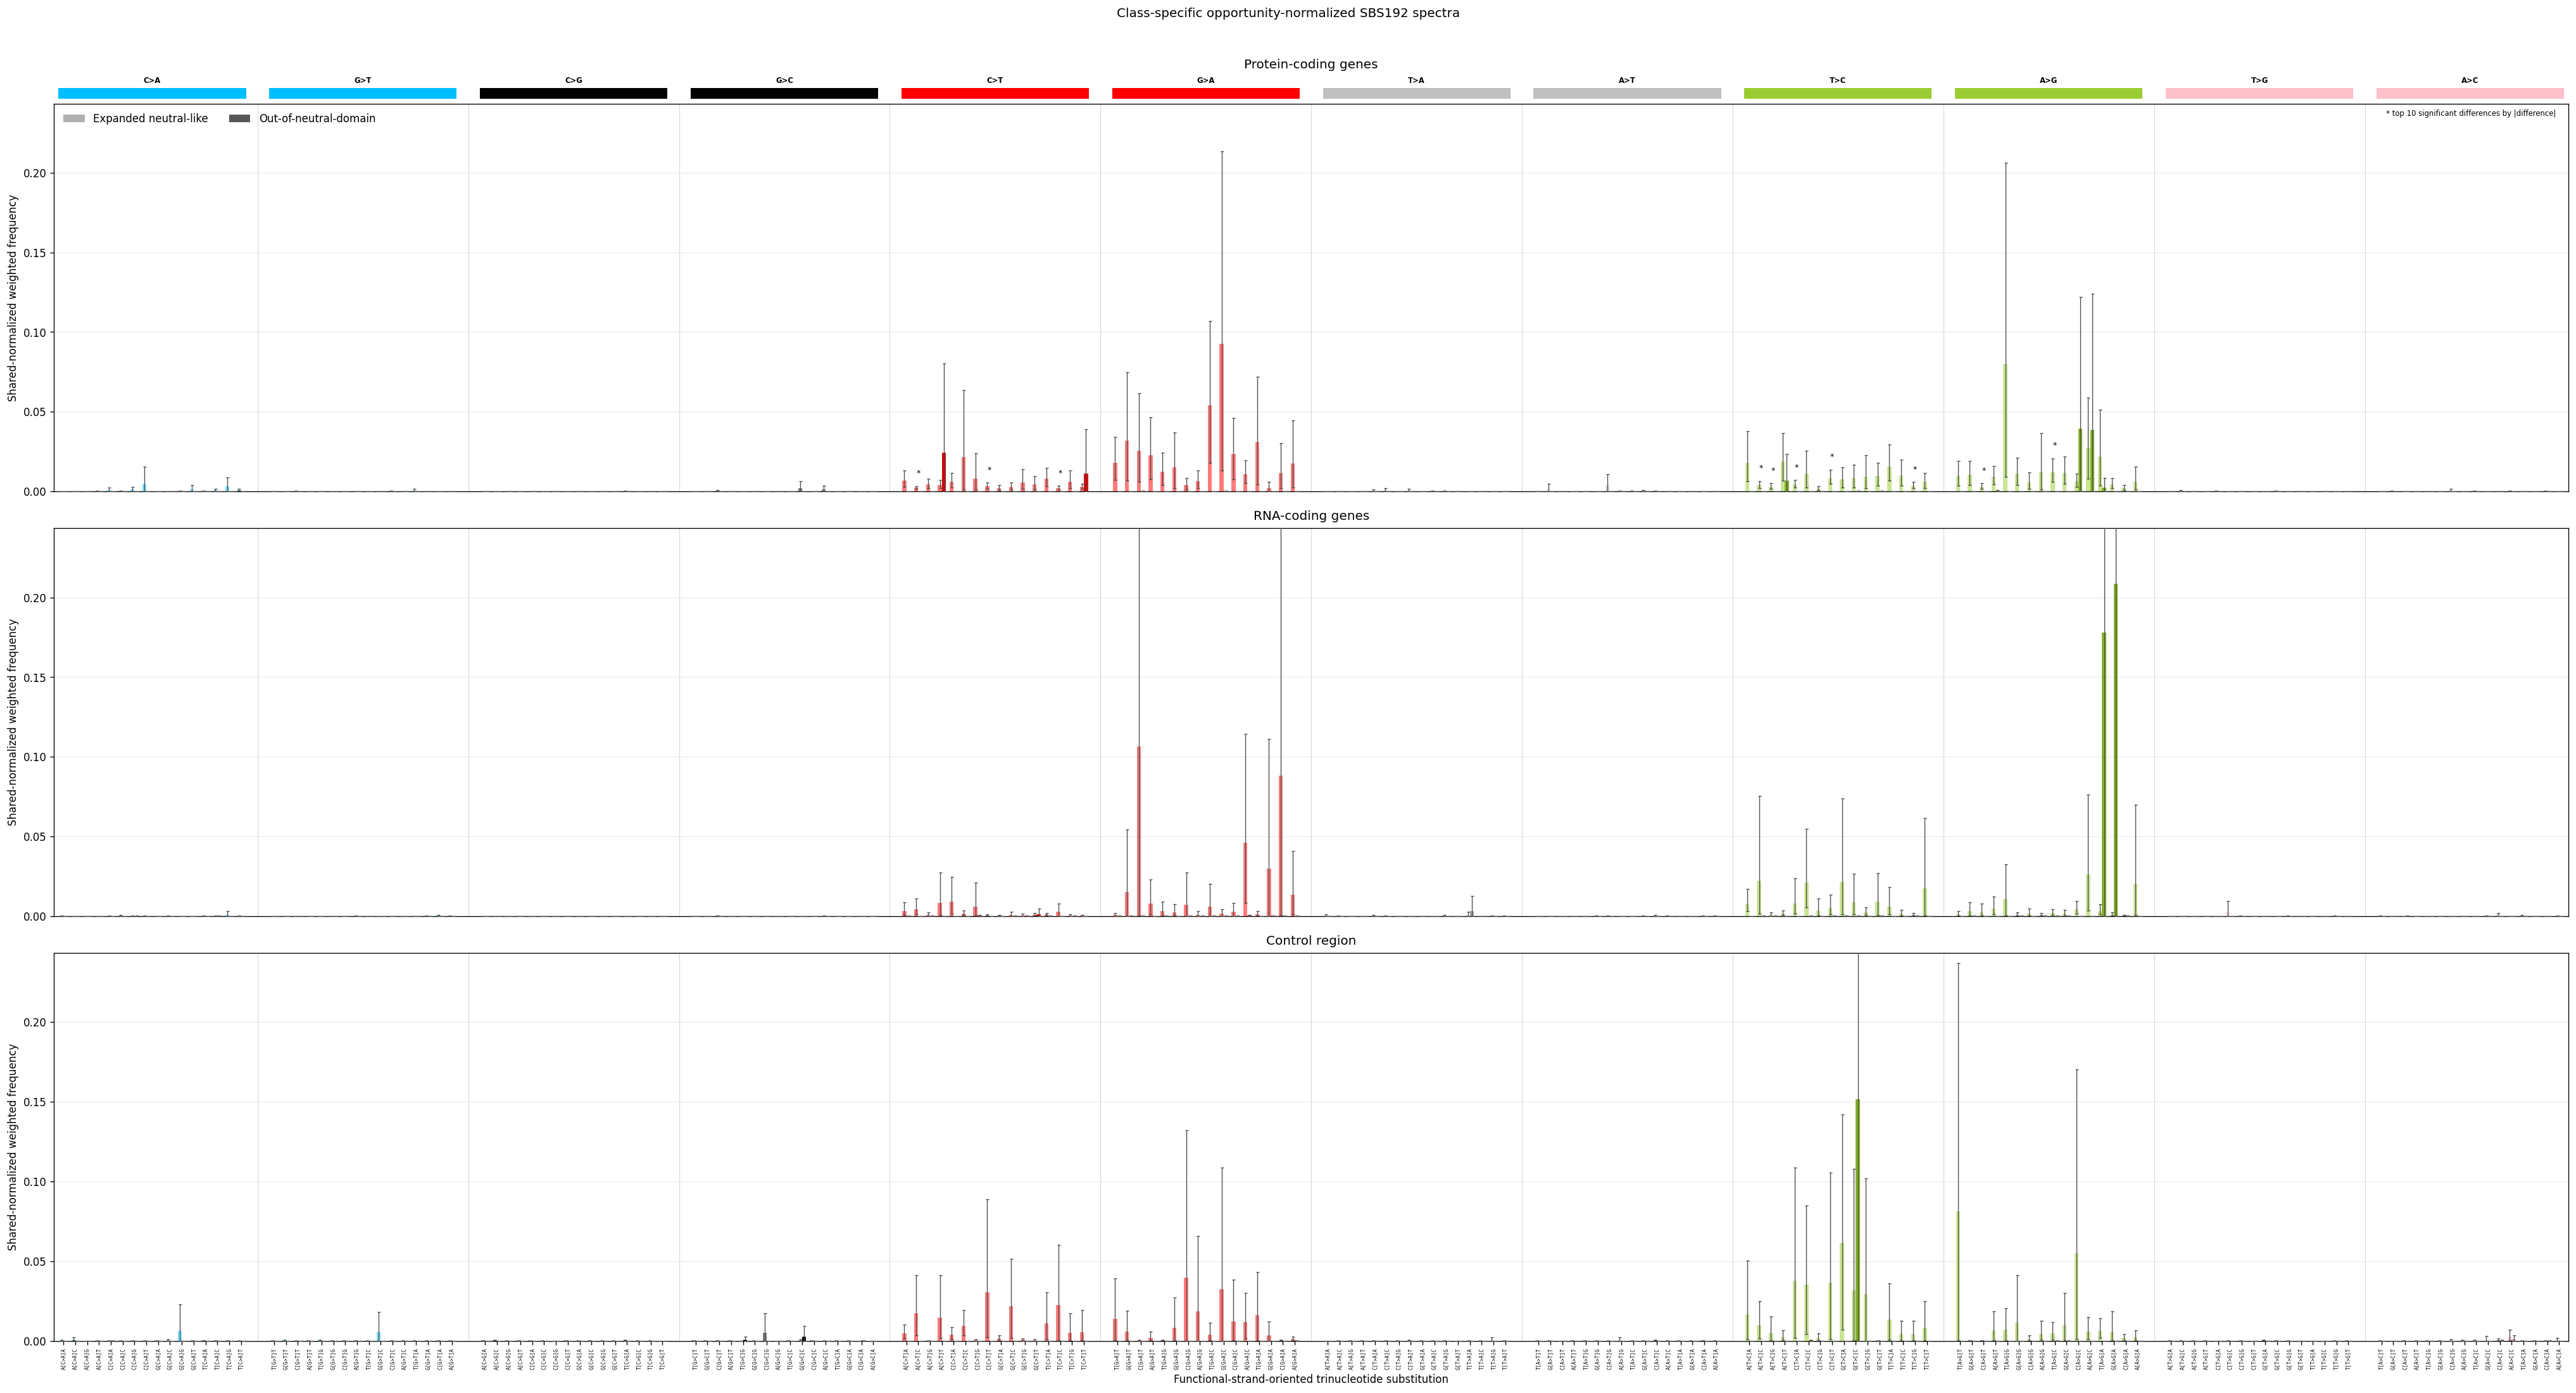

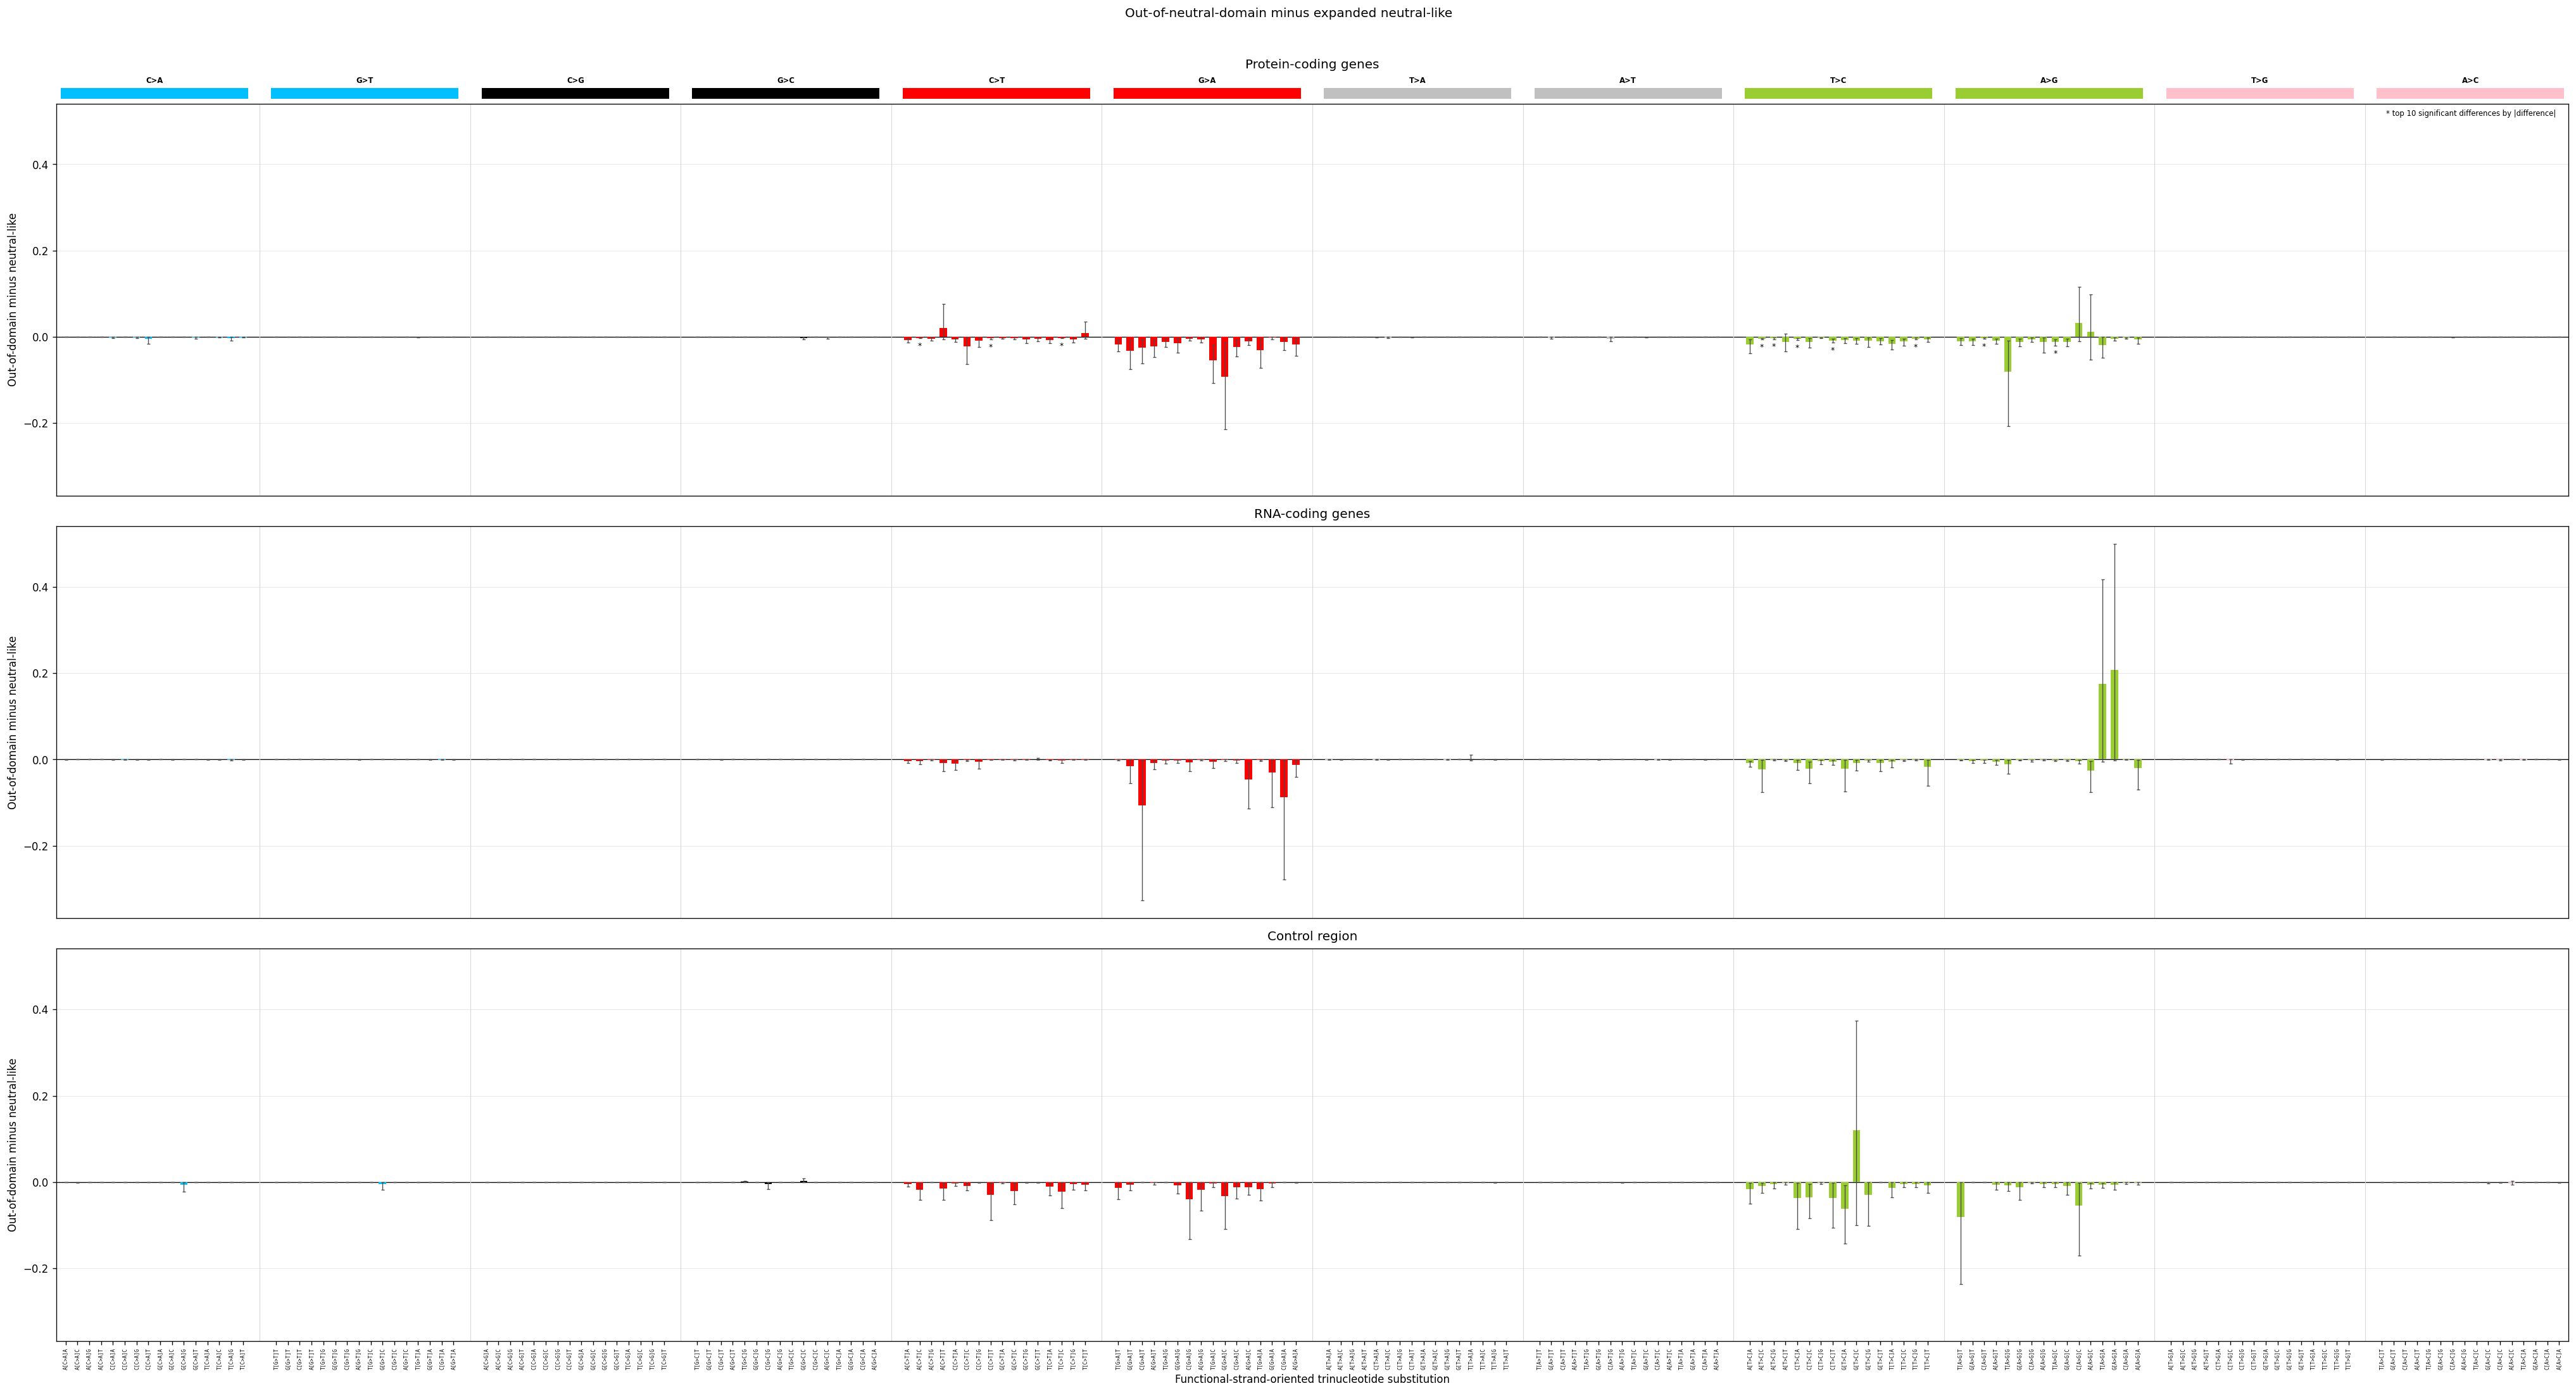

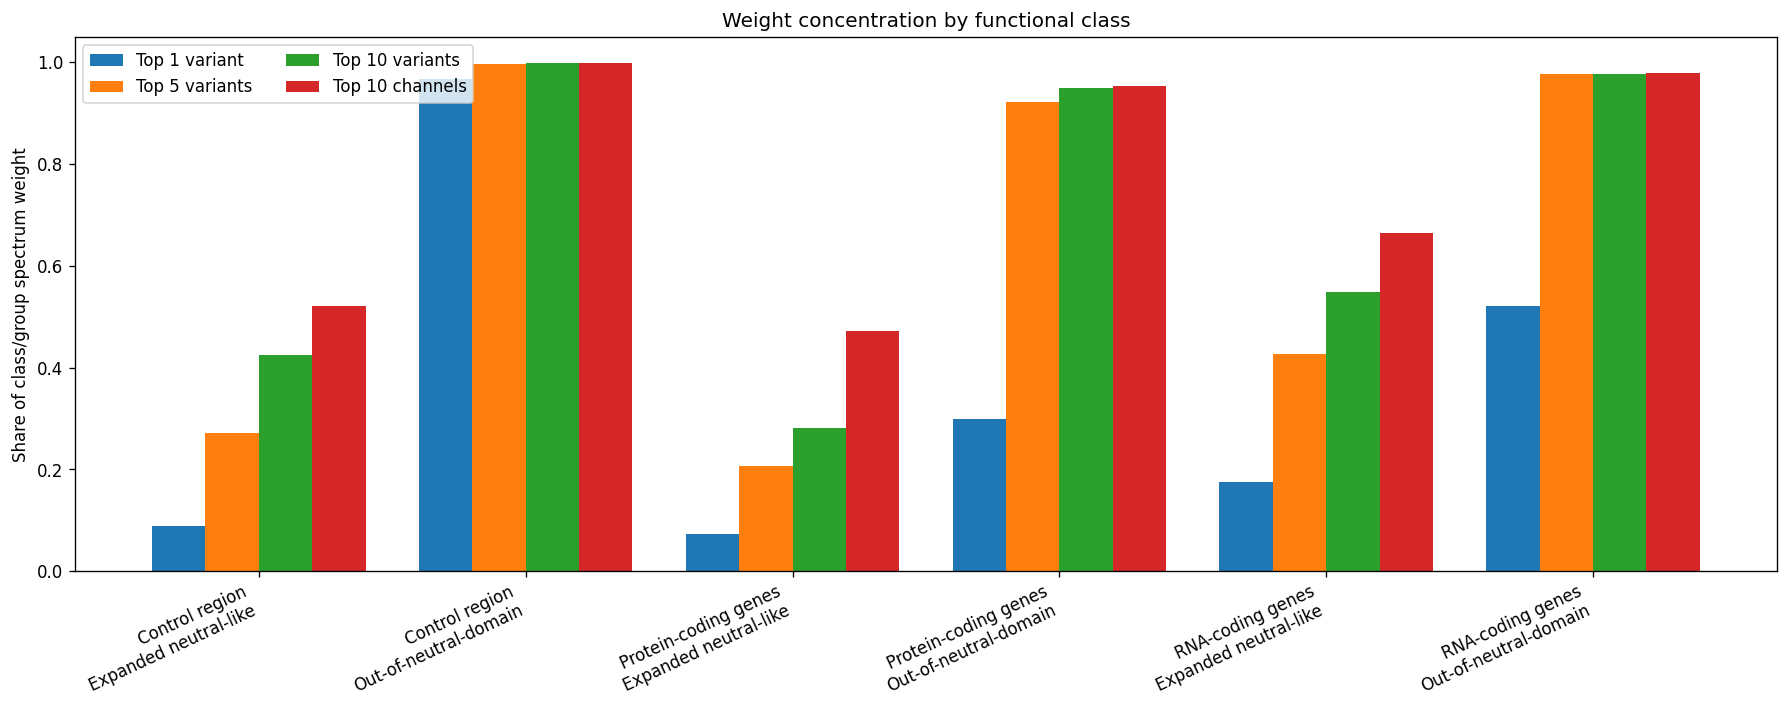

In [9]:
comparison_192_path = FIGURE_DIR / "functional_class_spectra_192_T95.png"
difference_192_path = FIGURE_DIR / "functional_class_spectrum_differences_192_T95.png"
concentration_path = FIGURE_DIR / "functional_class_weight_concentration_192_T95.png"

plot_faceted_192_comparison(main_spectrum, comparison_192_path)
plot_faceted_192_difference(main_spectrum, difference_192_path)
plot_weight_concentration(class_group_summary, concentration_path)

print("Saved figures:")
for path in [
    comparison_192_path,
    difference_192_path,
    concentration_path,
]:
    print("-", path)